# NeuroQWERTY keyboard dynamics - sélection stricte du protocole et du modèle

Ce notebook vise à choisir proprement la meilleure configuration pour la modalité clavier.

Contrairement aux notebooks précédents, l'objectif ici n'est pas seulement de tester une idée, mais de comparer de manière stricte :

- longueur minimale des segments (`min_len`) ;
- familles de modèles ;
- features complètes vs `timing-only` ;
- sélection PSO vs pas de sélection ;
- seuil de décision ;
- export optionnel de la meilleure configuration.

La méthodologie est volontairement plus rigoureuse :

```text
outer StratifiedGroupKFold par sujet
  train subjects uniquement
    inner StratifiedGroupKFold par sujet
      sélection des paramètres, modèle, features, PSO, seuil
  validation subjects jamais vus
    évaluation finale de la configuration choisie
```

Cela évite de choisir les features ou les hyperparamètres sur les sujets utilisés pour l'évaluation finale.


## 0. Configuration

`RUN_FULL_EXPERIMENT = False` lance un smoke test rapide pour vérifier le notebook.

Pour l'expérience complète, passer à `True`. L'exécution complète peut prendre longtemps, surtout avec PSO, Voting et Stacking.


In [15]:
from pathlib import Path
import itertools
import json
import re
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pyswarms.discrete import BinaryPSO
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
# Presets disponibles:
# - "smoke": validation rapide du notebook, pas pour conclure.
# - "balanced": recommandé; méthodologie stricte, mais espace de recherche raisonnable.
# - "full": très coûteux; teste aussi PSO sur Voting/Stacking.
EXPERIMENT_PRESET = "balanced"
SAVE_FINAL_MODEL = True

ROOT = Path.cwd()
if not (ROOT / "data" / "neuroqwerty-mit-csxpd-dataset-1.0.0").exists() and ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_ROOT = ROOT / "data" / "neuroqwerty-mit-csxpd-dataset-1.0.0"
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

if EXPERIMENT_PRESET == "smoke":
    OUTER_SPLITS = 3
    INNER_SPLITS = 2
    SEGMENT_MIN_LENS = [120, 300]
    FEATURE_MODES = ["all", "timing"]
    SELECTION_MODES = ["none", "pso"]
    MODEL_NAMES = ["histgb", "random_forest"]
    PSO_MODEL_NAMES = ["histgb", "random_forest"]
    PSO_PARTICLES = 8
    PSO_ITERS = 4
elif EXPERIMENT_PRESET == "balanced":
    OUTER_SPLITS = 5
    INNER_SPLITS = 3
    SEGMENT_MIN_LENS = [120, 200, 300]
    FEATURE_MODES = ["all", "timing"]
    SELECTION_MODES = ["none", "pso"]
    MODEL_NAMES = ["logreg", "svc", "random_forest", "extra_trees", "histgb", "voting", "stacking"]
    # PSO sur les modèles rapides/moyens seulement. Voting/Stacking restent testés sans PSO.
    PSO_MODEL_NAMES = ["logreg", "svc", "random_forest", "extra_trees", "histgb"]
    PSO_PARTICLES = 12
    PSO_ITERS = 8
elif EXPERIMENT_PRESET == "full":
    OUTER_SPLITS = 5
    INNER_SPLITS = 3
    SEGMENT_MIN_LENS = [120, 200, 300]
    FEATURE_MODES = ["all", "timing"]
    SELECTION_MODES = ["none", "pso"]
    MODEL_NAMES = ["logreg", "svc", "random_forest", "extra_trees", "histgb", "voting", "stacking"]
    PSO_MODEL_NAMES = MODEL_NAMES
    PSO_PARTICLES = 18
    PSO_ITERS = 12
else:
    raise ValueError(f"Unknown EXPERIMENT_PRESET: {EXPERIMENT_PRESET}")

print("ROOT", ROOT)
print("EXPERIMENT_PRESET", EXPERIMENT_PRESET)
print("PSO_MODEL_NAMES", PSO_MODEL_NAMES)



def format_seconds(seconds):
    seconds = max(0, float(seconds))
    hours, remainder = divmod(int(seconds), 3600)
    minutes, secs = divmod(remainder, 60)
    if hours:
        return f"{hours}h{minutes:02d}m{secs:02d}s"
    if minutes:
        return f"{minutes}m{secs:02d}s"
    return f"{secs}s"


ROOT /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection
EXPERIMENT_PRESET balanced
PSO_MODEL_NAMES ['logreg', 'svc', 'random_forest', 'extra_trees', 'histgb']


## Note sur le temps de calcul et la parallélisation

Le notebook affiche une progression détaillée pendant la sélection imbriquée :

- numéro du fold externe ;
- configuration candidate en cours ;
- temps par configuration ;
- ETA du fold ;
- ETA globale ;
- progression interne de PSO.

La parallélisation est déjà utilisée dans les modèles scikit-learn qui l'acceptent (`RandomForest`, `ExtraTrees`, `Voting`, `Stacking` via `n_jobs=-1`). En revanche, les folds externes et les configurations ne sont pas parallélisés entre eux pour garder l'exécution lisible et éviter de saturer la machine avec des modèles eux-mêmes parallèles.

Le preset recommandé est `EXPERIMENT_PRESET = "balanced"`. Il conserve une méthodologie stricte mais évite `PSO + Voting/Stacking`, qui est trop coûteux pour un gain probablement marginal. `Voting` et `Stacking` restent quand même évalués sans PSO.


## 1. Chargement et nettoyage NeuroQWERTY

On réutilise un loader simple et lisible pour les CSV bruts. Les sujets restent les groupes de validation.


In [16]:
KEY_COLUMNS = ["key", "hold_time", "release_time", "press_time"]
MOUSE_RE = re.compile(r'"?mouse.+"?', re.I)
LONG_META_RE = re.compile(r'"?(Shift.+|Alt.+|Control.+)"?', re.I)
BACKSPACE_RE = re.compile(r'"?BackSpace"?', re.I)
PUNCT_OR_SPACE_RE = re.compile(r'"?(space|comma|period|semicolon|slash|minus|equal|apostrophe|Return)"?', re.I)
LEFT_KEYS = set("qwertasdfgzxcvb")
RIGHT_KEYS = set("yuiophjklnm")


def load_raw(path):
    df = pd.read_csv(path, header=None, names=KEY_COLUMNS)
    df["key"] = df["key"].astype(str).str.strip().str.replace('"', "", regex=False)
    for column in ["hold_time", "release_time", "press_time"]:
        df[column] = pd.to_numeric(df[column], errors="coerce")
    return df


def clean(df):
    d = df.dropna(subset=["hold_time", "release_time", "press_time"]).copy()
    key = d["key"].astype(str)
    keep = ~key.str.match(MOUSE_RE) & ~key.str.match(LONG_META_RE) & ~key.str.match(BACKSPACE_RE)
    d = d.loc[keep]
    d = d[(d.press_time > 0) & (d.release_time > 0) & (d.hold_time.between(0, 5))]
    d = d.sort_values("press_time").reset_index(drop=True)
    d["flight_time"] = d.press_time.diff()
    d.loc[d.flight_time < 0, "flight_time"] = np.nan
    d["is_space_punct"] = d.key.str.match(PUNCT_OR_SPACE_RE).astype(int)
    d["hand_left"] = d.key.str.lower().str[:1].isin(LEFT_KEYS).astype(int)
    d["hand_right"] = d.key.str.lower().str[:1].isin(RIGHT_KEYS).astype(int)
    d["hand_switch"] = (d.hand_left.diff().abs().fillna(0) > 0).astype(int)
    return d


def load_sessions():
    rows = []
    raws = {}
    for dataset in ["MIT-CS1PD", "MIT-CS2PD"]:
        gt = pd.read_csv(DATA_ROOT / dataset / f"GT_DataPD_{dataset}.csv")
        raw_dir = DATA_ROOT / dataset / f"data_{dataset}"
        for _, subject in gt.iterrows():
            for file_col in [column for column in gt.columns if column.startswith("file_")]:
                filename = subject.get(file_col)
                if pd.isna(filename) or not str(filename).strip():
                    continue
                session_uid = f"{dataset}_{int(subject.pID)}_{file_col}"
                raw_path = raw_dir / str(filename)
                cleaned = clean(load_raw(raw_path))
                raws[session_uid] = cleaned
                rows.append({
                    "session_uid": session_uid,
                    "dataset": dataset,
                    "pID": int(subject.pID),
                    "session_file": str(filename),
                    "session_id": file_col,
                    "label": int(bool(subject["gt"])),
                    "n_keys": len(cleaned),
                })
    return pd.DataFrame(rows), raws


sessions, raw_sessions = load_sessions()
print("sessions", len(sessions), "subjects", sessions.pID.nunique())
display(sessions.groupby("label").agg(sessions=("label", "size"), subjects=("pID", "nunique")))


sessions 116 subjects 85


,sessions,subjects
label,,
0,56,43
1,60,42


## 2. Construction des features par longueur de segment

On prépare les tables pour toutes les longueurs candidates. La sélection finale de `min_len` se fait uniquement dans les folds internes.


In [17]:
def safe_div(a, b):
    return np.nan if b is None or pd.isna(b) or abs(b) < 1e-12 else a / b


def entropy_binary(p):
    if pd.isna(p) or p <= 0 or p >= 1:
        return 0.0
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))


def agg_features(d):
    hold = d.hold_time.dropna()
    flight = d.flight_time.dropna()
    duration = d.release_time.max() - d.press_time.min() if len(d) else np.nan
    out = {
        "n_keystrokes": len(d),
        "duration_sec": duration,
        "keys_per_min": safe_div(len(d) * 60, duration),
        "mean_hold": hold.mean(),
        "std_hold": hold.std(),
        "median_hold": hold.median(),
        "iqr_hold": hold.quantile(0.75) - hold.quantile(0.25),
        "q10_hold": hold.quantile(0.1),
        "q90_hold": hold.quantile(0.9),
        "skew_hold": hold.skew(),
        "kurt_hold": hold.kurt(),
        "cv_hold": safe_div(hold.std(), hold.mean()),
        "mean_flight": flight.mean(),
        "std_flight": flight.std(),
        "median_flight": flight.median(),
        "iqr_flight": flight.quantile(0.75) - flight.quantile(0.25),
        "q10_flight": flight.quantile(0.1),
        "q90_flight": flight.quantile(0.9),
        "skew_flight": flight.skew(),
        "kurt_flight": flight.kurt(),
        "cv_flight": safe_div(flight.std(), flight.mean()),
        "hold_to_flight": safe_div(hold.mean(), flight.mean()),
        "long_hold_rate": (hold > hold.quantile(0.9)).mean() if len(hold) > 5 else np.nan,
        "long_flight_rate": (flight > 1.0).mean() if len(flight) > 5 else np.nan,
        "space_punct_rate": d.is_space_punct.mean(),
        "left_rate": d.hand_left.mean(),
        "right_rate": d.hand_right.mean(),
        "hand_switch_rate": d.hand_switch.mean(),
    }
    out["hand_entropy"] = entropy_binary(out["left_rate"])
    return out


def build_segment_features(window=300, stride=150, min_len=300):
    rows = []
    for _, session in sessions.iterrows():
        d = raw_sessions[session.session_uid]
        starts = list(range(0, max(len(d) - min_len + 1, 0), stride))
        for segment_id, start in enumerate(starts):
            segment = d.iloc[start:min(start + window, len(d))]
            if len(segment) < min_len:
                continue
            rows.append({
                **session.to_dict(),
                "segment_id": segment_id,
                "segment_start": start,
                "segment_len": len(segment),
                **agg_features(segment),
            })
    return pd.DataFrame(rows)


segment_tables = {min_len: build_segment_features(min_len=min_len) for min_len in SEGMENT_MIN_LENS}
for min_len, table in segment_tables.items():
    print(min_len, table.shape, "sessions", table.session_uid.nunique(), "subjects", table.pID.nunique())


120 (1090, 39) sessions 116 subjects 85
200 (1032, 39) sessions 116 subjects 85
300 (951, 39) sessions 115 subjects 84


## 3. Modèles, features et utilitaires

Le score d'évaluation principal est le F1 macro au niveau session. On garde aussi accuracy, balanced accuracy, precision, recall et matrice de confusion.


In [18]:
META_COLS = ["session_uid", "dataset", "pID", "session_file", "session_id", "label", "n_keys", "segment_id", "segment_start", "segment_len"]
LAYOUT_FEATURES = ["space_punct_rate", "left_rate", "right_rate", "hand_switch_rate", "hand_entropy"]


def feature_columns(table, mode):
    features = [column for column in table.columns if column not in META_COLS]
    features = [column for column in features if pd.api.types.is_numeric_dtype(table[column])]
    if mode == "timing":
        features = [feature for feature in features if feature not in LAYOUT_FEATURES]
    return features


def model_factory(name):
    if name == "logreg":
        return LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
    if name == "svc":
        return SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE)
    if name == "random_forest":
        return RandomForestClassifier(n_estimators=400, min_samples_leaf=2, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)
    if name == "extra_trees":
        return ExtraTreesClassifier(n_estimators=400, min_samples_leaf=2, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
    if name == "histgb":
        return HistGradientBoostingClassifier(max_iter=200, learning_rate=0.04, l2_regularization=0.1, random_state=RANDOM_STATE)
    if name == "voting":
        return VotingClassifier(
            estimators=[
                ("lr", model_factory("logreg")),
                ("svc", model_factory("svc")),
                ("rf", model_factory("random_forest")),
                ("et", model_factory("extra_trees")),
            ],
            voting="soft",
            n_jobs=-1,
        )
    if name == "stacking":
        return StackingClassifier(
            estimators=[
                ("lr", model_factory("logreg")),
                ("svc", model_factory("svc")),
                ("rf", model_factory("random_forest")),
                ("et", model_factory("extra_trees")),
            ],
            final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
            stack_method="predict_proba",
            n_jobs=-1,
        )
    raise ValueError(f"Unknown model: {name}")


def make_pipeline(model_name):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model_factory(model_name)),
    ])


def aggregate_segment_predictions(table, valid_idx, probabilities, threshold):
    tmp = table.iloc[valid_idx][["session_uid", "pID", "label"]].copy()
    tmp["proba"] = probabilities
    agg = tmp.groupby("session_uid").agg(
        label=("label", "first"),
        pID=("pID", "first"),
        proba_mean=("proba", "mean"),
        n_segments=("proba", "size"),
    ).reset_index()
    agg["pred"] = (agg.proba_mean >= threshold).astype(int)
    return agg


def metrics_from_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_binary": f1_score(y_true, y_pred),
        "precision_binary": precision_score(y_true, y_pred, zero_division=0),
        "recall_binary": recall_score(y_true, y_pred, zero_division=0),
    }


## 4. Évaluation interne et sélection du seuil

Pour chaque configuration candidate, les folds internes produisent des prédictions out-of-fold sur les sujets d'entraînement externe. Le seuil est choisi sur ces prédictions internes, puis la configuration est évaluée une seule fois sur le fold externe.


In [19]:
def inner_cv_oof(table, features, model_name, train_subjects, n_splits=INNER_SPLITS):
    train_table = table[table.pID.isin(train_subjects)].copy()
    X = train_table[features]
    y = train_table.label.astype(int)
    groups = train_table.pID.astype(str)
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    oof = []
    fold_rows = []
    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y, groups), 1):
        clf = make_pipeline(model_name)
        clf.fit(X.iloc[train_idx], y.iloc[train_idx])
        probabilities = clf.predict_proba(X.iloc[valid_idx])[:, 1]
        agg = aggregate_segment_predictions(train_table, valid_idx, probabilities, threshold=0.5)
        fold_rows.append({"inner_fold": fold, **metrics_from_predictions(agg.label, agg.pred)})
        oof.append(agg.assign(inner_fold=fold))
    return pd.concat(oof, ignore_index=True), pd.DataFrame(fold_rows)


def choose_threshold(oof, thresholds=np.linspace(0.2, 0.8, 61)):
    rows = []
    for threshold in thresholds:
        pred = (oof.proba_mean >= threshold).astype(int)
        rows.append({"threshold": threshold, **metrics_from_predictions(oof.label, pred)})
    threshold_df = pd.DataFrame(rows)
    best = threshold_df.sort_values(["f1_macro", "balanced_accuracy"], ascending=False).iloc[0]
    return float(best.threshold), threshold_df


## 5. PSO imbriqué dans les données d'entraînement

PSO est appelé uniquement sur les sujets d'entraînement du fold externe. Le fold externe ne sert jamais à sélectionner les features.


In [20]:
def pso_select_features_nested(table, candidate_features, model_name, train_subjects, n_particles=PSO_PARTICLES, iters=PSO_ITERS, feature_penalty=0.015, progress_label=""):
    candidate_features = list(candidate_features)
    cache = {}
    pso_start = time.time()
    objective_calls = {"count": 0}

    def objective(masks):
        costs = []
        objective_calls["count"] += 1
        call_start = time.time()
        new_masks = 0
        for mask in masks:
            selected = [feature for feature, keep in zip(candidate_features, mask.astype(bool)) if keep]
            if not selected:
                costs.append(1.0)
                continue
            key = tuple(selected)
            if key not in cache:
                new_masks += 1
                oof, _ = inner_cv_oof(table, selected, model_name, train_subjects)
                threshold, _ = choose_threshold(oof)
                pred = (oof.proba_mean >= threshold).astype(int)
                mean_f1 = f1_score(oof.label, pred, average="macro")
                penalty = feature_penalty * (len(selected) / len(candidate_features))
                cache[key] = 1.0 - mean_f1 + penalty
            costs.append(cache[key])
        print(
            f"      PSO {progress_label} call {objective_calls['count']}/{iters}: "
            f"particles={len(masks)}, new_masks={new_masks}, cache={len(cache)}, "
            f"elapsed={format_seconds(time.time() - pso_start)}, call={format_seconds(time.time() - call_start)}",
            flush=True,
        )
        return np.array(costs)

    print(
        f"    PSO start {progress_label}: features={len(candidate_features)}, particles={n_particles}, iters={iters}",
        flush=True,
    )
    options = {"c1": 0.8, "c2": 0.8, "w": 0.7, "k": min(8, n_particles - 1), "p": 2}
    optimizer = BinaryPSO(n_particles=n_particles, dimensions=len(candidate_features), options=options)
    best_cost, best_pos = optimizer.optimize(objective, iters=iters, verbose=False)
    selected = [feature for feature, keep in zip(candidate_features, best_pos.astype(bool)) if keep]
    print(
        f"    PSO end {progress_label}: selected={len(selected)}, best_cost={best_cost:.4f}, "
        f"elapsed={format_seconds(time.time() - pso_start)}",
        flush=True,
    )
    return selected, float(best_cost)


## 6. Boucle de sélection imbriquée

Cette cellule est la plus longue. En mode complet, elle teste toutes les combinaisons configurées en haut du notebook.


In [21]:
def evaluate_on_outer_fold(table, features, model_name, train_subjects, test_subjects, threshold):
    train_table = table[table.pID.isin(train_subjects)].copy()
    test_table = table[table.pID.isin(test_subjects)].copy()
    clf = make_pipeline(model_name)
    clf.fit(train_table[features], train_table.label.astype(int))
    probabilities = clf.predict_proba(test_table[features])[:, 1]
    agg = aggregate_segment_predictions(test_table, np.arange(len(test_table)), probabilities, threshold=threshold)
    return agg, metrics_from_predictions(agg.label, agg.pred)


def candidate_configs():
    for min_len, feature_mode, selection_mode, model_name in itertools.product(
        SEGMENT_MIN_LENS,
        FEATURE_MODES,
        SELECTION_MODES,
        MODEL_NAMES,
    ):
        if selection_mode == "pso" and model_name not in PSO_MODEL_NAMES:
            continue
        yield {
            "min_len": min_len,
            "feature_mode": feature_mode,
            "selection_mode": selection_mode,
            "model_name": model_name,
        }


def estimate_eta(start_time, completed, total):
    if completed <= 0:
        return "unknown"
    elapsed = time.time() - start_time
    remaining = elapsed / completed * (total - completed)
    return format_seconds(remaining)


def run_nested_selection():
    subject_df = sessions[["pID", "label"]].drop_duplicates("pID").sort_values("pID")
    outer_cv = StratifiedGroupKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    outer_rows = []
    selected_rows = []
    outer_predictions = []

    configs = list(candidate_configs())
    total_candidates = len(configs)
    total_steps = OUTER_SPLITS * total_candidates
    global_start = time.time()
    completed_steps = 0

    print(
        f"Nested selection plan: outer_folds={OUTER_SPLITS}, candidates_per_fold={total_candidates}, "
        f"total_candidate_evals={total_steps}",
        flush=True,
    )
    print(
        f"Search space: min_len={SEGMENT_MIN_LENS}, feature_modes={FEATURE_MODES}, "
        f"selection_modes={SELECTION_MODES}, models={MODEL_NAMES}",
        flush=True,
    )

    X_subject = subject_df[["pID"]]
    y_subject = subject_df.label.astype(int)
    groups_subject = subject_df.pID.astype(str)

    for outer_fold, (train_subject_idx, test_subject_idx) in enumerate(outer_cv.split(X_subject, y_subject, groups_subject), 1):
        fold_start = time.time()
        train_subjects = set(subject_df.iloc[train_subject_idx].pID)
        test_subjects = set(subject_df.iloc[test_subject_idx].pID)
        print("\n" + "=" * 96, flush=True)
        print(
            f"Outer fold {outer_fold}/{OUTER_SPLITS}: train_subjects={len(train_subjects)} "
            f"test_subjects={len(test_subjects)}",
            flush=True,
        )

        candidate_rows = []
        candidate_payloads = []
        for candidate_idx, config in enumerate(configs, 1):
            candidate_start = time.time()
            print(
                f"  Candidate {candidate_idx}/{total_candidates} | global {completed_steps + 1}/{total_steps} | "
                f"min_len={config['min_len']} feature={config['feature_mode']} "
                f"selection={config['selection_mode']} model={config['model_name']}",
                flush=True,
            )
            table = segment_tables[config["min_len"]]
            base_features = feature_columns(table, config["feature_mode"])
            if config["selection_mode"] == "pso":
                label = f"outer={outer_fold} candidate={candidate_idx} model={config['model_name']} min_len={config['min_len']} {config['feature_mode']}"
                selected_features, pso_cost = pso_select_features_nested(
                    table,
                    base_features,
                    config["model_name"],
                    train_subjects,
                    progress_label=label,
                )
            else:
                selected_features, pso_cost = base_features, np.nan

            oof, inner_fold_metrics = inner_cv_oof(table, selected_features, config["model_name"], train_subjects)
            threshold, threshold_df = choose_threshold(oof)
            pred = (oof.proba_mean >= threshold).astype(int)
            inner_metrics = metrics_from_predictions(oof.label, pred)
            row = {
                **config,
                "outer_fold": outer_fold,
                "n_features": len(selected_features),
                "features": selected_features,
                "threshold": threshold,
                "pso_cost": pso_cost,
                **{f"inner_{key}": value for key, value in inner_metrics.items()},
            }
            candidate_rows.append(row)
            candidate_payloads.append((row, table, selected_features))
            completed_steps += 1
            print(
                f"    done in {format_seconds(time.time() - candidate_start)} | "
                f"inner_f1={inner_metrics['f1_macro']:.3f} inner_bal_acc={inner_metrics['balanced_accuracy']:.3f} "
                f"threshold={threshold:.2f} n_features={len(selected_features)} | "
                f"fold_elapsed={format_seconds(time.time() - fold_start)} "
                f"fold_eta={estimate_eta(fold_start, candidate_idx, total_candidates)} "
                f"global_eta={estimate_eta(global_start, completed_steps, total_steps)}",
                flush=True,
            )

        candidates_df = pd.DataFrame(candidate_rows)
        best_idx = candidates_df.sort_values(["inner_f1_macro", "inner_balanced_accuracy"], ascending=False).index[0]
        best_row, best_table, best_features = candidate_payloads[list(candidates_df.index).index(best_idx)]
        test_agg, test_metrics = evaluate_on_outer_fold(
            best_table,
            best_features,
            best_row["model_name"],
            train_subjects,
            test_subjects,
            best_row["threshold"],
        )
        selected_rows.append(best_row)
        outer_rows.append({
            "outer_fold": outer_fold,
            **{key: best_row[key] for key in ["min_len", "feature_mode", "selection_mode", "model_name", "n_features", "threshold"]},
            **test_metrics,
            "elapsed_sec": time.time() - fold_start,
        })
        outer_predictions.append(test_agg.assign(outer_fold=outer_fold))
        print(
            f"Outer fold {outer_fold} selected: "
            f"min_len={best_row['min_len']} feature={best_row['feature_mode']} "
            f"selection={best_row['selection_mode']} model={best_row['model_name']} "
            f"n_features={best_row['n_features']} threshold={best_row['threshold']:.2f}",
            flush=True,
        )
        print(f"Outer fold {outer_fold} metrics: {test_metrics}", flush=True)
        print(f"Outer fold {outer_fold} elapsed: {format_seconds(time.time() - fold_start)}", flush=True)

    print(f"Total elapsed: {format_seconds(time.time() - global_start)}", flush=True)
    return pd.DataFrame(outer_rows), pd.DataFrame(selected_rows), pd.concat(outer_predictions, ignore_index=True)


outer_results, selected_configs, outer_oof = run_nested_selection()
display(outer_results)
display(outer_results.drop(columns=["outer_fold", "elapsed_sec"]).select_dtypes(include="number").agg(["mean", "std"]).round(3))
display(selected_configs[["outer_fold", "min_len", "feature_mode", "selection_mode", "model_name", "n_features", "threshold", "features"]])

Nested selection plan: outer_folds=5, candidates_per_fold=72, total_candidate_evals=360
Search space: min_len=[120, 200, 300], feature_modes=['all', 'timing'], selection_modes=['none', 'pso'], models=['logreg', 'svc', 'random_forest', 'extra_trees', 'histgb', 'voting', 'stacking']

Outer fold 1/5: train_subjects=68 test_subjects=17
  Candidate 1/72 | global 1/360 | min_len=120 feature=all selection=none model=logreg
    done in 0s | inner_f1=0.746 inner_bal_acc=0.748 threshold=0.33 n_features=29 | fold_elapsed=0s fold_eta=18s global_eta=1m38s
  Candidate 2/72 | global 2/360 | min_len=120 feature=all selection=none model=svc
    done in 0s | inner_f1=0.728 inner_bal_acc=0.729 threshold=0.52 n_features=29 | fold_elapsed=0s fold_eta=20s global_eta=1m44s
  Candidate 3/72 | global 3/360 | min_len=120 feature=all selection=none model=random_forest
    done in 1s | inner_f1=0.761 inner_bal_acc=0.762 threshold=0.54 n_features=29 | fold_elapsed=1s fold_eta=44s global_eta=3m52s
  Candidate 4/72 

,outer_fold,min_len,feature_mode,selection_mode,model_name,n_features,threshold,accuracy,balanced_accuracy,f1_macro,f1_binary,precision_binary,recall_binary,elapsed_sec
0,1,300,timing,pso,random_forest,12,0.60,0.625000,0.632867,0.624348,0.608696,0.700000,0.538462,1467.004487
1,2,300,all,pso,svc,15,0.51,0.818182,0.825000,0.818182,0.818182,0.750000,0.900000,1525.553981
2,3,120,all,pso,svc,16,0.42,0.720000,0.708333,0.688057,0.787879,0.650000,1.000000,1535.182686
3,4,200,all,pso,svc,15,0.54,0.458333,0.458333,0.433757,0.315789,0.428571,0.250000,1574.048509
4,5,300,timing,pso,svc,10,0.49,0.714286,0.750000,0.708333,0.666667,1.000000,0.500000,1434.475715


,min_len,n_features,threshold,accuracy,balanced_accuracy,f1_macro,f1_binary,precision_binary,recall_binary
mean,244.000,13.60,0.512,0.667,0.675,0.655,0.639,0.706,0.638
std,81.731,2.51,0.066,0.135,0.140,0.142,0.200,0.205,0.308


,outer_fold,min_len,feature_mode,selection_mode,model_name,n_features,threshold,features
0,1,300,timing,pso,random_forest,12,0.60,"[n_keystrokes, duration_sec, keys_per_min, mea..."
1,2,300,all,pso,svc,15,0.51,"[n_keystrokes, keys_per_min, std_hold, median_..."
2,3,120,all,pso,svc,16,0.42,"[duration_sec, keys_per_min, median_hold, q10_..."
3,4,200,all,pso,svc,15,0.54,"[iqr_hold, q10_hold, skew_hold, kurt_hold, cv_..."
4,5,300,timing,pso,svc,10,0.49,"[n_keystrokes, std_hold, cv_hold, std_flight, ..."


## 7. Résultats finaux stricts

Ces métriques sont les plus importantes : elles viennent uniquement des folds externes.


              precision    recall  f1-score   support

    Contrôle       0.64      0.70      0.67        56
   Parkinson       0.69      0.63      0.66        60

    accuracy                           0.66       116
   macro avg       0.67      0.66      0.66       116
weighted avg       0.67      0.66      0.66       116



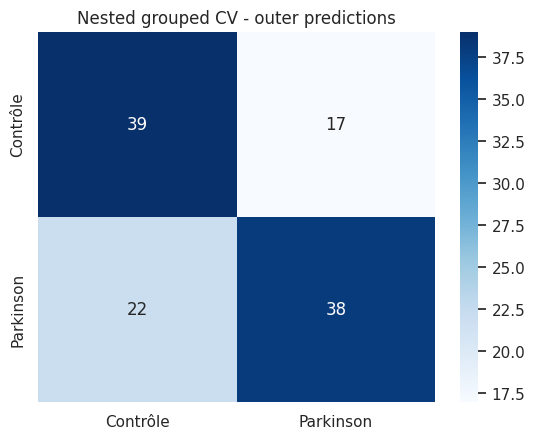

,accuracy,balanced_accuracy,f1_macro,f1_binary,precision_binary,recall_binary
mean,0.667,0.675,0.655,0.639,0.706,0.638
std,0.135,0.140,0.142,0.200,0.205,0.308


In [22]:
print(classification_report(outer_oof.label, outer_oof.pred, target_names=["Contrôle", "Parkinson"]))
cm = confusion_matrix(outer_oof.label, outer_oof.pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Contrôle", "Parkinson"], yticklabels=["Contrôle", "Parkinson"])
plt.title("Nested grouped CV - outer predictions")
plt.show()

summary_cols = ["accuracy", "balanced_accuracy", "f1_macro", "f1_binary", "precision_binary", "recall_binary"]
summary = outer_results[summary_cols].agg(["mean", "std"]).round(3)
display(summary)


## 8. Choix final et export optionnel

Après l'évaluation stricte, on peut exporter une configuration candidate pour l'application. Cet export doit être relu avant de remplacer le modèle actuellement utilisé, car le choix automatique par configuration la plus fréquente peut être fragile si plusieurs configurations sont à égalité.


In [23]:
config_counts = selected_configs.groupby(["min_len", "feature_mode", "selection_mode", "model_name"]).size().reset_index(name="count").sort_values("count", ascending=False)
display(config_counts)

best_config = config_counts.iloc[0].to_dict()
print("Most frequently selected config:", best_config)

if SAVE_FINAL_MODEL:
    min_len = int(best_config["min_len"])
    table = segment_tables[min_len]
    base_features = feature_columns(table, best_config["feature_mode"])
    if best_config["selection_mode"] == "pso":
        all_subjects = set(sessions.pID.unique())
        final_features, _ = pso_select_features_nested(table, base_features, best_config["model_name"], all_subjects)
    else:
        final_features = base_features

    # Choose final threshold from grouped OOF on all subjects.
    all_subjects = set(sessions.pID.unique())
    final_oof, _ = inner_cv_oof(table, final_features, best_config["model_name"], all_subjects, n_splits=OUTER_SPLITS)
    final_threshold, _ = choose_threshold(final_oof)

    final_model = make_pipeline(best_config["model_name"])
    final_model.fit(table[final_features], table.label.astype(int))
    artifact = {
        "pipeline": final_model,
        "features": final_features,
        "model": best_config["model_name"],
        "level": "segment_mean_agg",
        "segment_min_len": min_len,
        "threshold": float(final_threshold),
        "note": "NeuroQWERTY rigorous nested grouped CV selection.",
    }
    path = MODEL_DIR / "keyboard_dynamics_neuroqwerty_rigorous_selected.joblib"
    joblib.dump(artifact, path)
    print(path)
else:
    print("No model exported. Set SAVE_FINAL_MODEL=True after reviewing the nested CV results.")


,min_len,feature_mode,selection_mode,model_name,count
0,120,all,pso,svc,1
1,200,all,pso,svc,1
2,300,all,pso,svc,1
3,300,timing,pso,random_forest,1
4,300,timing,pso,svc,1


Most frequently selected config: {'min_len': 120, 'feature_mode': 'all', 'selection_mode': 'pso', 'model_name': 'svc', 'count': 1}
    PSO start : features=29, particles=12, iters=8
      PSO  call 1/8: particles=12, new_masks=12, cache=12, elapsed=3s, call=3s
      PSO  call 2/8: particles=12, new_masks=8, cache=20, elapsed=6s, call=2s
      PSO  call 3/8: particles=12, new_masks=8, cache=28, elapsed=9s, call=2s
      PSO  call 4/8: particles=12, new_masks=11, cache=39, elapsed=12s, call=3s
      PSO  call 5/8: particles=12, new_masks=9, cache=48, elapsed=15s, call=3s
      PSO  call 6/8: particles=12, new_masks=10, cache=58, elapsed=19s, call=3s
      PSO  call 7/8: particles=12, new_masks=10, cache=68, elapsed=22s, call=3s
      PSO  call 8/8: particles=12, new_masks=12, cache=80, elapsed=26s, call=4s
    PSO end : selected=12, best_cost=0.2045, elapsed=26s
/home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection/models/keyboard_dynamics_neuroqwerty_rigorous_s

## 9. Analyse du run `balanced`

Le run `balanced` a exécuté 5 folds externes groupés par sujet, avec 72 configurations candidates par fold, soit 360 évaluations candidates au total. La sélection de la longueur de segment, du mode de features, du modèle, de PSO et du seuil a été faite dans les folds internes uniquement. Les métriques ci-dessus sont donc les métriques strictes sur sujets externes.

Résultat global sur les folds externes :

- accuracy moyenne : `0.667 ± 0.135` ;
- balanced accuracy moyenne : `0.675 ± 0.140` ;
- F1 macro moyen : `0.655 ± 0.142` ;
- F1 Parkinson moyen : `0.639 ± 0.200` ;
- précision Parkinson moyenne : `0.706 ± 0.205` ;
- rappel Parkinson moyen : `0.638 ± 0.308`.

La matrice de confusion agrégée est :

| Classe réelle | Prédit contrôle | Prédit Parkinson |
|---|---:|---:|
| Contrôle | 39 | 17 |
| Parkinson | 22 | 38 |

Les configurations retenues varient fortement selon les folds :

- PSO est sélectionné dans les 5 folds externes ;
- SVC est sélectionné dans 4 folds sur 5 ;
- Random Forest est sélectionné dans 1 fold ;
- `min_len=300` est sélectionné dans 3 folds sur 5 ;
- `timing-only` est sélectionné dans 2 folds sur 5 ;
- aucune configuration exacte ne domine vraiment, car chaque configuration exacte n'apparaît qu'une seule fois.

L'interprétation principale est que les résultats exploratoires précédents étaient probablement optimistes. En validation imbriquée groupée, le signal clavier reste réel, mais modéré et instable selon les sujets laissés de côté. Le clavier est donc pertinent comme modalité complémentaire dans la fusion tardive, mais il ne faut pas le présenter comme un test autonome fiable.

Pour le prototype navigateur, la décision la plus prudente est de garder au moins 300 frappes, de conserver une sortie non médicale, et de tester manuellement le modèle exporté avant de remplacer le modèle actuellement branché dans l'application.
